<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [5]:
print(df.info())
print(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB
None          ResponseId                      MainBranch              Age  \
count   65447.000000                           65447            65447   
unique           NaN                               5                8   
top              NaN  I am a developer by profession  25-34 years old   
freq             NaN                           50212            23911   
mean    32714.001528                             NaN              NaN   
std     18893.063225                             NaN              NaN   
min         1.000000                             NaN              NaN   
25%     16352.500000                             NaN              NaN   
50%     32714.000000                             NaN              NaN   
75%     49075.500000                             NaN              NaN   
max     65437.000000  

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(missing_summary)

                            Missing Count  Missing %
AINextMuch less integrated          64299  98.245909
AINextLess integrated               63092  96.401669
AINextNo change                     52947  80.900576
AINextMuch more integrated          52008  79.465827
EmbeddedAdmired                     48711  74.428163
...                                   ...        ...
YearsCode                            5569   8.509175
NEWSOSites                           5151   7.870491
LearnCode                            4949   7.561844
EdLevel                              4653   7.109570
AISelect                             4530   6.921631

[109 rows x 2 columns]

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



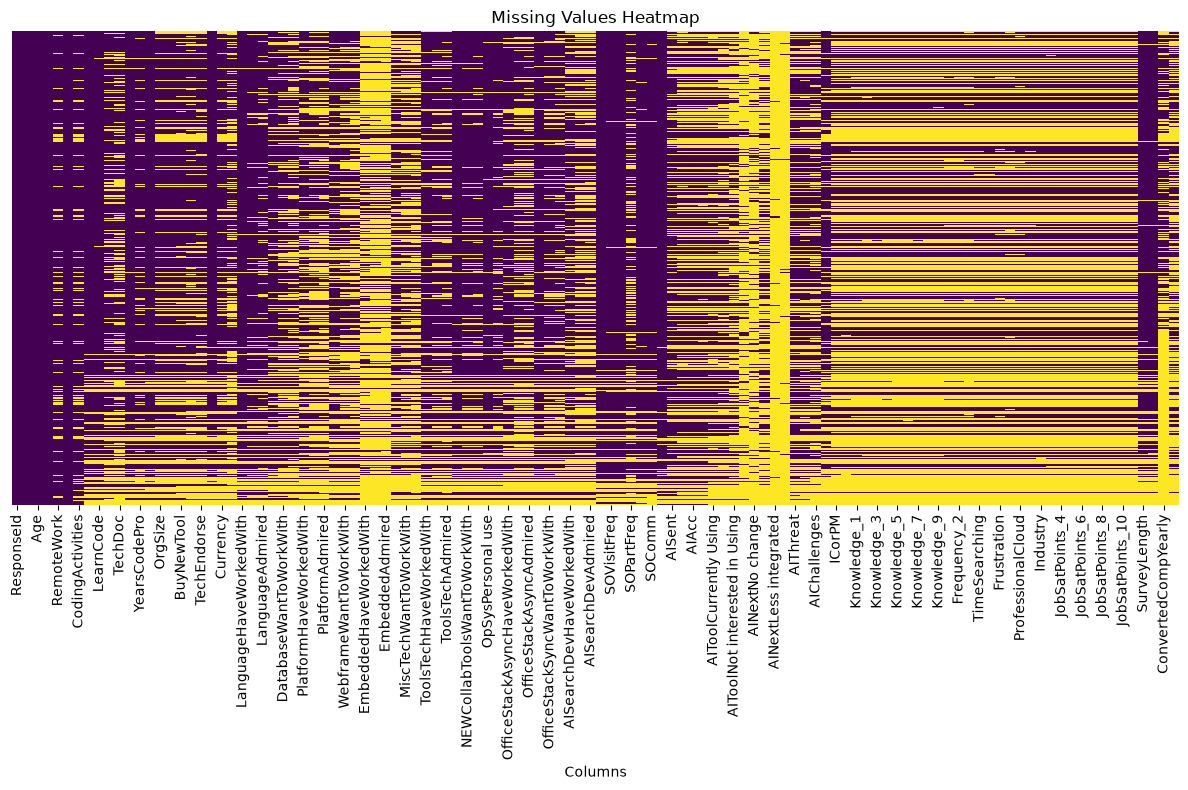

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [9]:
missing_employment = df['Employment'].isnull().sum()
print("Missing values in Employment:", missing_employment)

Missing values in Employment: 0

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [13]:
most_frequent_employment = df['Employment'].mode()[0]
print("Most frequent value:", most_frequent_employment)

Most frequent value: Employed, full-time

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [14]:
df['Employment'] = df['Employment'].fillna(most_frequent_employment)

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


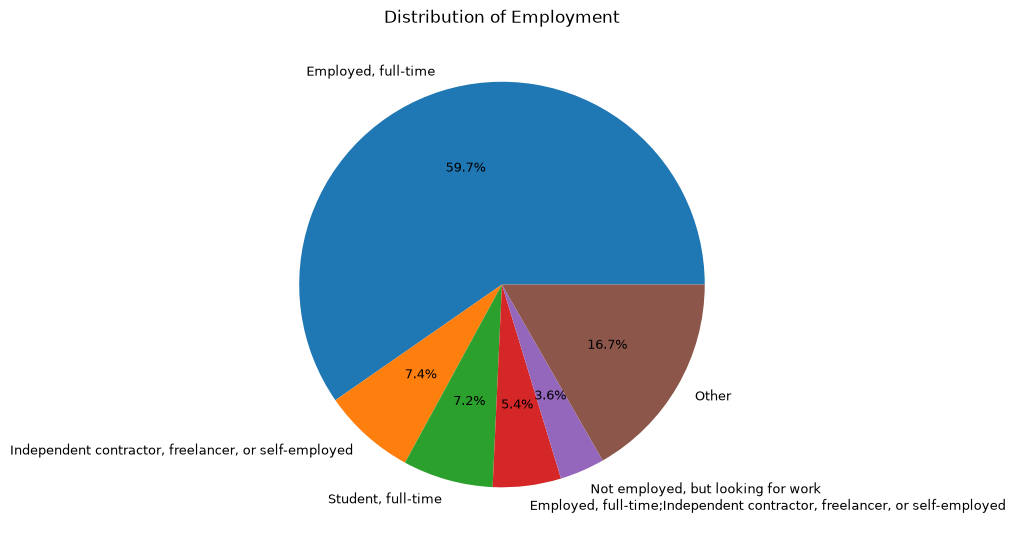

In [18]:
counts = df['Employment'].value_counts()
threshold = counts.sum() * 0.03  # anything under 3% gets grouped
main = counts[counts >= threshold]
other = pd.Series({'Other': counts[counts < threshold].sum()})
counts_grouped = pd.concat([main, other])

plt.figure(figsize=(9, 9))
plt.pie(counts_grouped, labels=counts_grouped.index, autopct='%1.1f%%', textprops={'fontsize': 9})
plt.title('Distribution of Employment')
plt.tight_layout()
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
